## LIBRERIAS NECESARIAS PARA EL PROYECTO

In [185]:
import pandas as pd  # carga la libreria pandas para el manejo de datos
import numpy as np  # carga la libreria numpy para el manejo de arreglos y matrices
import warnings # carga la libreria warnings para manejar advertencias
import random # carga la libreria random para generar numeros aleatorios

import matplotlib.pyplot as plt # carga la libreria matplotlib para graficar
import seaborn as sns # carga la libreria seaborn para graficar

import sklearn #carga la libreria sklearn para el manejo de modelos de machine learning
from scipy.stats import zscore # carga la funcion zscore para normalizar los datos
from sklearn.model_selection import train_test_split # carga la funcion train_test_split para dividir los datos en entrenamiento y prueba
from sklearn.impute import SimpleImputer # carga la clase SimpleImputer para manejar los valores faltantes
from sklearn.preprocessing import StandardScaler # carga la clase StandardScaler para escalar los datos
from sklearn.ensemble import RandomForestClassifier # carga la clase RandomForestClassifier para crear un modelo de bosque aleatorio
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score # carga las funciones para evaluar el modelo
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

CARGA Y EXPLORACION DEL DATASET

In [186]:
df = pd.read_csv('heart_disease_uci.csv') # carga el dataset desde un archivo CSV
df.head() # muestra las primeras filas del dataset

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [187]:
df.describe() # muestra un resumen estadístico del dataset

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [188]:
df.info() # muestra información sobre el dataset, incluyendo tipos de datos y valores nulos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [189]:
df.isnull().sum() # muestra la cantidad de valores nulos en cada columna del dataset

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [190]:
df.nunique() # muestra la cantidad de valores únicos en cada columna del dataset

id          920
age          50
sex           2
dataset       4
cp            4
trestbps     61
chol        217
fbs           2
restecg       3
thalch      119
exang         2
oldpeak      53
slope         3
ca            4
thal          3
num           5
dtype: int64

In [191]:
df.columns # muestra los nombres de las columnas del dataset

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

In [192]:
df.columns = df.columns.str.replace(' ', '_') # reemplaza los espacios en los nombres de las columnas por guiones bajos
df.columns = df.columns.str.lower() # convierte los nombres de las columnas a minúsculas
print(df.columns) # muestra los nombres de las columnas

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')


In [193]:
def snake_columns(df):
	df.columns = df.columns.str.replace(' ', '_')
	df.columns = df.columns.str.lower()
	print(df.columns)

snake_columns(df) # muestra los nombres de las columnas en formato snake_case

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')


In [194]:
df["cp"].value_counts() # muestra la cantidad de ocurrencias de cada valor en la columna "cp" (tipo de dolor en el pecho)

cp
asymptomatic       496
non-anginal        204
atypical angina    174
typical angina      46
Name: count, dtype: int64

La variable objetivo del dataset es la columna llamada "num". Esta columna indica la presencia o ausencia de enfermedad cardíaca, generalmente codificada como valores binarios (por ejemplo, 0 para ausencia y 1 para presencia de enfermedad). Es la variable que queremos predecir utilizando un modelo de clasificación en este proyecto

In [195]:
df["num"].value_counts() # muestra la cantidad de ocurrencias de cada valor en la columna "num" (diagnóstico de enfermedad cardíaca)

num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

In [196]:
df.sample(5) # muestra 5 filas aleatorias del dataset

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
114,115,62,Female,Cleveland,non-anginal,130.0,263.0,False,normal,97.0,False,1.2,flat,1.0,reversable defect,2
383,384,46,Male,Hungary,non-anginal,120.0,230.0,False,normal,150.0,False,0.0,NaN,NaN,NaN,0
341,342,39,Male,Hungary,asymptomatic,110.0,273.0,False,normal,132.0,False,0.0,NaN,NaN,NaN,0
329,330,37,Male,Hungary,asymptomatic,130.0,315.0,False,normal,158.0,False,0.0,NaN,NaN,NaN,0
412,413,50,Female,Hungary,atypical angina,110.0,202.0,False,normal,145.0,False,0.0,NaN,NaN,NaN,0


In [197]:
df_backup = df.copy() # crea una copia de seguridad del dataframe

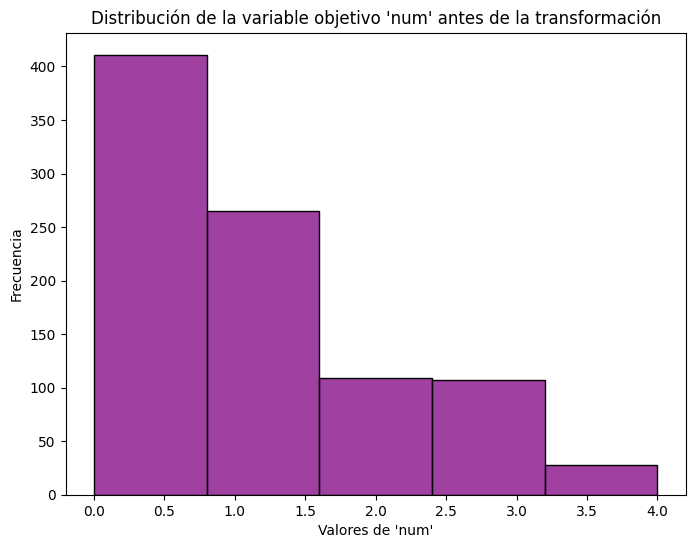

In [198]:
# Histograma de la variable objetivo antes de la transformación donde se observa la distribución de la variable objetivo "num" y su tendencia a estar sesgada hacia la clase 0 (sin enfermedad cardíaca).
plt.figure(figsize=(8, 6))
sns.histplot(df["num"], bins=5, kde=False, color="purple")
plt.title("Distribución de la variable objetivo 'num' antes de la transformación")
plt.xlabel("Valores de 'num'")
plt.ylabel("Frecuencia")
plt.show()

In [199]:
df.shape # muestra la forma del dataframe (filas, columnas)

(920, 16)

## PREPROCESAMIENTO (LIMPIEZA, ENCODING, ESCALADO)

In [200]:
## Transformación de la variable objetivo "num" para convertirla en una variable binaria (0 o 1) donde 0 representa la ausencia de enfermedad cardíaca y 1 representa la presencia de enfermedad cardíaca.
df["num"] = df["num"].apply(lambda x: 0 if x == 0 else 1) 
print("\nDistribución de la variable objetivo 'num' después de la transformación:")
print(df["num"].value_counts())


Distribución de la variable objetivo 'num' después de la transformación:
num
1    509
0    411
Name: count, dtype: int64


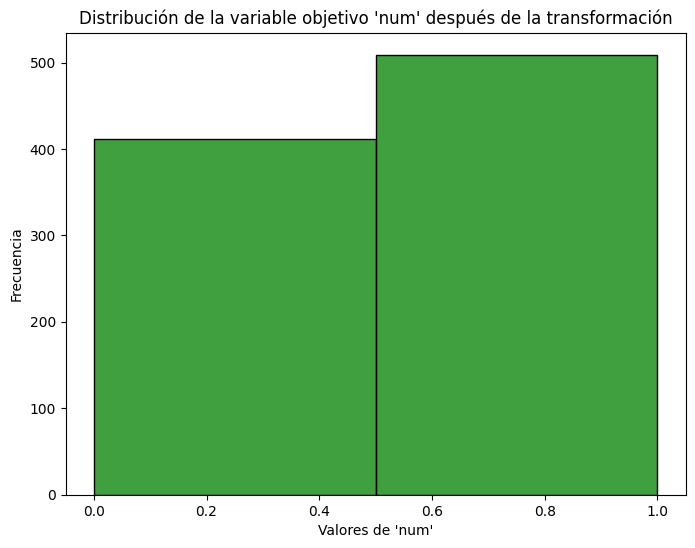

In [201]:
# Histograma de la variable objetivo después de la transformación
plt.figure(figsize=(8, 6))
sns.histplot(df["num"], bins=2, kde=False, color="green")
plt.title("Distribución de la variable objetivo 'num' después de la transformación")
plt.xlabel("Valores de 'num'")
plt.ylabel("Frecuencia")
plt.show()

In [202]:
df.head() # muestra las primeras filas del dataframe después de la transformación

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,1
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [203]:
df = df.set_index("id") # establece la columna "id" como índice del dataframe
df.head() # muestra las primeras filas del dataframe con el nuevo índice

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
id,,,,,,,,,,,,,,,
1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,1
3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [204]:
# Identificar columnas con valores nulos
columnas_con_nulos = df.columns[df.isnull().any()].tolist()

print("Columnas con valores nulos antes de la imputación:", columnas_con_nulos)

Columnas con valores nulos antes de la imputación: ['trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [205]:
columns_to_drop = ['thal', 'ca', 'slope', 'dataset']
columns_to_drop_existing = [col for col in columns_to_drop if col in df.columns]
df = df.drop(columns=columns_to_drop_existing)
print(f"Columnas eliminadas: {columns_to_drop_existing}")


Columnas eliminadas: ['thal', 'ca', 'slope', 'dataset']


In [206]:
# Rellenar valores numéricos con la media
numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns
imputer_mean = SimpleImputer(strategy="mean")
df[numeric_cols] = imputer_mean.fit_transform(df[numeric_cols])

# Rellenar valores categóricos con la moda
categorical_cols = df.select_dtypes(include=["object"]).columns
imputer_mode = SimpleImputer(strategy="most_frequent")
if len(categorical_cols) > 0:
    df[categorical_cols] = imputer_mode.fit_transform(df[categorical_cols])

In [207]:
print("\nValores nulos después del tratamiento:")
print(df.isnull().sum())


Valores nulos después del tratamiento:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
num         0
dtype: int64



🔍 Analizando outliers...

Descripción estadística de 'age':
count    920.000000
mean      53.510870
std        9.424685
min       28.000000
25%       47.000000
50%       54.000000
75%       60.000000
max       77.000000
Name: age, dtype: float64


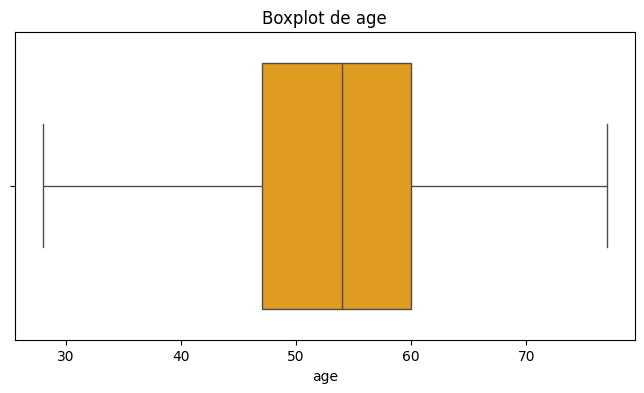


Descripción estadística de 'trestbps':
count    920.000000
mean     132.132404
std       18.443895
min        0.000000
25%      120.000000
50%      130.000000
75%      140.000000
max      200.000000
Name: trestbps, dtype: float64


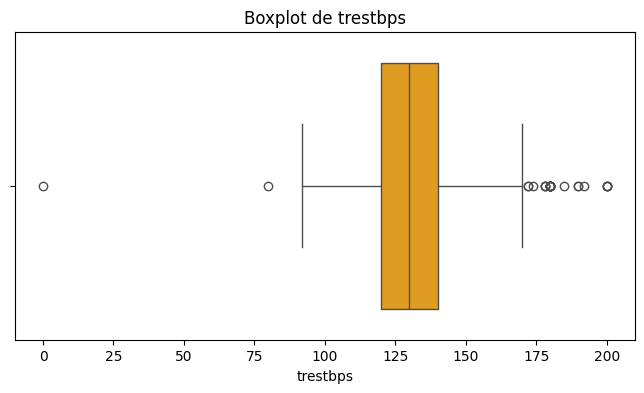


Descripción estadística de 'chol':
count    920.000000
mean     199.130337
std      108.957634
min        0.000000
25%      177.750000
50%      221.000000
75%      267.000000
max      603.000000
Name: chol, dtype: float64


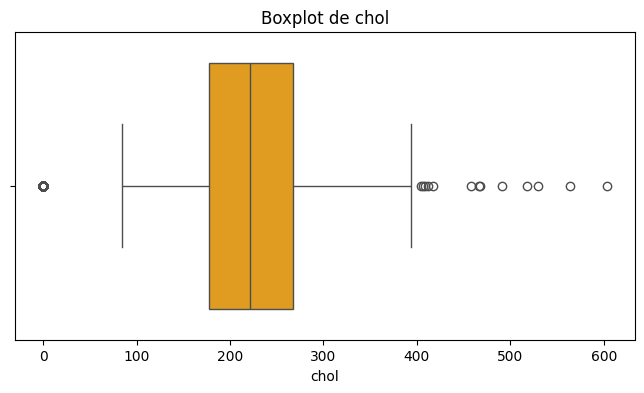


Descripción estadística de 'thalch':
count    920.000000
mean     137.545665
std       25.138494
min       60.000000
25%      120.000000
50%      138.000000
75%      156.000000
max      202.000000
Name: thalch, dtype: float64


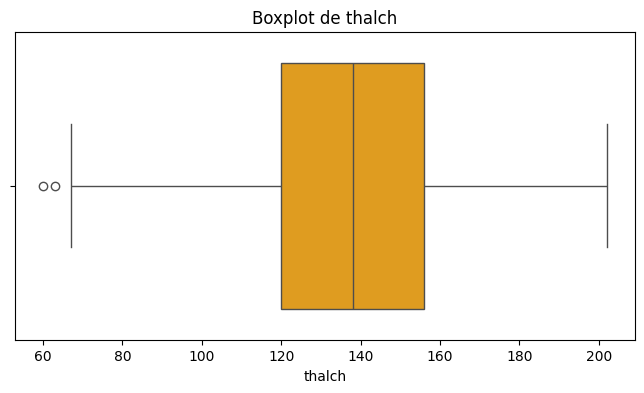


Descripción estadística de 'oldpeak':
count    920.000000
mean       0.878788
std        1.053774
min       -2.600000
25%        0.000000
50%        0.800000
75%        1.500000
max        6.200000
Name: oldpeak, dtype: float64


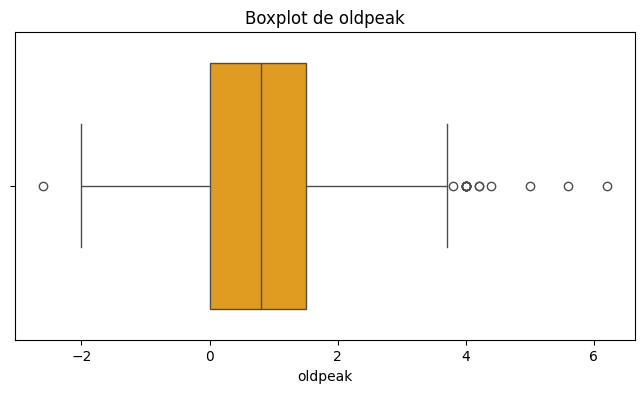


Descripción estadística de 'num':
count    920.000000
mean       0.553261
std        0.497426
min        0.000000
25%        0.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: num, dtype: float64


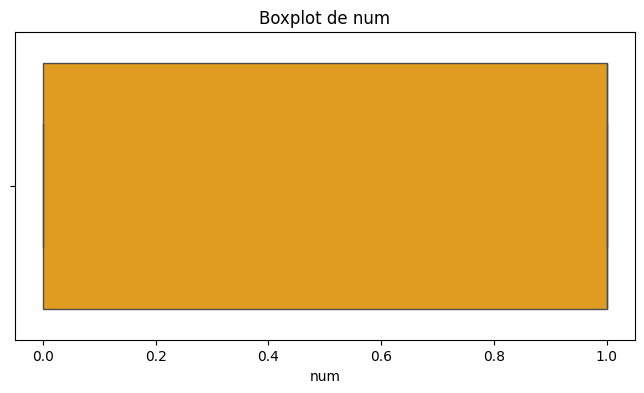


🔍 Detectando outliers usando z-score...
Columna 'age' - Número de outliers detectados: 0
Columna 'trestbps' - Número de outliers detectados: 8
Columna 'chol' - Número de outliers detectados: 3
Columna 'thalch' - Número de outliers detectados: 1
Columna 'oldpeak' - Número de outliers detectados: 7
Columna 'num' - Número de outliers detectados: 0

📌 Tratando los outliers...

Datos después de tratar los outliers:
     age     sex               cp  trestbps   chol    fbs         restecg  \
id                                                                          
1   63.0    Male   typical angina     145.0  233.0   True  lv hypertrophy   
2   67.0    Male     asymptomatic     160.0  286.0  False  lv hypertrophy   
3   67.0    Male     asymptomatic     120.0  229.0  False  lv hypertrophy   
4   37.0    Male      non-anginal     130.0  250.0  False          normal   
5   41.0  Female  atypical angina     130.0  204.0  False  lv hypertrophy   

    thalch  exang  oldpeak  num  
id         

In [208]:
# Paso 1: Analizar outliers con boxplot y describe()
def analyze_outliers(df):
    print("\n🔍 Analizando outliers...")

    # Variables numéricas
    numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns
    for col in numeric_cols:
        print(f"\nDescripción estadística de '{col}':")
        print(df[col].describe())

        # Boxplot para visualizar outliers
        plt.figure(figsize=(8, 4))
        sns.boxplot(x=df[col], color="orange")
        plt.title(f"Boxplot de {col}")
        plt.xlabel(col)
        plt.show()

# Paso 2: Detectar outliers usando z-score
def detect_outliers(df):
    print("\n🔍 Detectando outliers usando z-score...")
    numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns
    outliers_dict = {}  # Diccionario para almacenar outliers por columna

    for col in numeric_cols:
        z_scores = zscore(df[col].dropna())  # Calcular z-score
        outliers = df[col][np.abs(z_scores) > 3]  # Filtrar valores fuera de 3 desv. estándar
        outliers_dict[col] = outliers
        print(f"Columna '{col}' - Número de outliers detectados: {len(outliers)}")

    return outliers_dict

# Paso 3: Tratar outliers (eliminar, limitar o transformar)
def treat_outliers(df):
    print("\n📌 Tratando los outliers...")

    # Elegir estrategia según caso (por ejemplo: eliminar)
    numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns
    for col in numeric_cols:
        z_scores = zscore(df[col].dropna())
        df.loc[np.abs(z_scores) > 3, col] = np.nan  # Marcar outliers como NaN para eliminarlos o transformarlos

    # Eliminar filas con NaN (opcional)
    df = df.dropna()

    print("\nDatos después de tratar los outliers:")
    print(df.head())
    return df

# Ejecutar análisis y tratamiento
analyze_outliers(df)  # Paso 1: Analizar outliers
outliers_detected = detect_outliers(df)  # Paso 2: Detectar outliers
df_cleaned = treat_outliers(df)  # Paso 3: Tratar outliers

In [209]:
# Separar columnas numéricas
numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns
print("\nColumnas numéricas:")
print(numeric_cols)

# Separar columnas categóricas
categorical_cols = df.select_dtypes(include=["object"]).columns
print("\nColumnas categóricas:")
print(categorical_cols)

# Crear DataFrames separados
df_numeric = df[numeric_cols]
df_categorical = df[categorical_cols]

# Mostrar las primeras filas de cada conjunto
print("\nPrimeras filas del DataFrame numérico:")
print(df_numeric.head())

print("\nPrimeras filas del DataFrame categórico:")
print(df_categorical.head())


Columnas numéricas:
Index(['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'num'], dtype='object')

Columnas categóricas:
Index(['sex', 'cp', 'fbs', 'restecg', 'exang'], dtype='object')

Primeras filas del DataFrame numérico:
     age  trestbps   chol  thalch  oldpeak  num
id                                             
1   63.0     145.0  233.0   150.0      2.3  0.0
2   67.0     160.0  286.0   108.0      1.5  1.0
3   67.0     120.0  229.0   129.0      2.6  1.0
4   37.0     130.0  250.0   187.0      3.5  0.0
5   41.0     130.0  204.0   172.0      1.4  0.0

Primeras filas del DataFrame categórico:
       sex               cp    fbs         restecg  exang
id                                                       
1     Male   typical angina   True  lv hypertrophy  False
2     Male     asymptomatic  False  lv hypertrophy   True
3     Male     asymptomatic  False  lv hypertrophy   True
4     Male      non-anginal  False          normal  False
5   Female  atypical angina  False  lv hypertro

In [210]:
# Mantener solo las columnas que no fueron eliminadas
columns_to_keep = ["age", "trestbps", "chol", "thalch", "oldpeak", "num", "sex", "cp", "fbs", "restecg", "exang"]
df = df[columns_to_keep]

print("\nDataset inicial:")
print(df.head())

# **Paso 1: Transformar columnas categóricas a formato binario o numérico**
# Mapeo binario para 'sex', 'fbs' y 'exang'
df["sex"] = df["sex"].map({"Male": 1, "Female": 0})
df["fbs"] = df["fbs"].map({True: 1, False: 0})
df["exang"] = df["exang"].map({True: 1, False: 0})

# Mapeo ordinal para 'cp'
cp_map = {
    "typical angina": 0,
    "atypical angina": 1,
    "non-anginal": 2,
    "asymptomatic": 3
}
df["cp"] = df["cp"].map(cp_map)

# Mapeo ordinal para 'restecg'
restecg_map = {
    "normal": 0,
    "st-t abnormality": 1,
    "lv hypertrophy": 2
}
df["restecg"] = df["restecg"].map(restecg_map)

# **Paso 2: Verificar y limpiar datos**
# Confirmar que no hay valores NaN generados
df.fillna(0, inplace=True)

# Mostrar el dataset transformado
print("\nDataset transformado:")
print(df.head())

# **Paso 3: Guardar el dataset transformado**
output_file = "heart_disease_binario.csv"  # Cambia el nombre si lo deseas
df.to_csv(output_file, index=False)
print(f"\nDataset transformado guardado en: {output_file}")



Dataset inicial:
     age  trestbps   chol  thalch  oldpeak  num     sex               cp  \
id                                                                         
1   63.0     145.0  233.0   150.0      2.3  0.0    Male   typical angina   
2   67.0     160.0  286.0   108.0      1.5  1.0    Male     asymptomatic   
3   67.0     120.0  229.0   129.0      2.6  1.0    Male     asymptomatic   
4   37.0     130.0  250.0   187.0      3.5  0.0    Male      non-anginal   
5   41.0     130.0  204.0   172.0      1.4  0.0  Female  atypical angina   

      fbs         restecg  exang  
id                                
1    True  lv hypertrophy  False  
2   False  lv hypertrophy   True  
3   False  lv hypertrophy   True  
4   False          normal  False  
5   False  lv hypertrophy  False  

Dataset transformado:
     age  trestbps   chol  thalch  oldpeak  num  sex  cp  fbs  restecg  exang
id                                                                           
1   63.0     145.0  233.0

In [211]:
# Import MinMaxScaler
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import boxcox  # Import boxcox for Box-Cox transformation

# Mantener las columnas relevantes
numeric_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'num']
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang']

# Mostrar las primeras filas del dataset
print("\nDataset inicial:")
print(df.head())

# **Paso 1: Escalado de columnas numéricas**
def scale_numeric_columns(df, numeric_cols):
    scaled_dfs = {}

    # Escalado con StandardScaler
    scaler_standard = StandardScaler()
    df_standard = df.copy()
    df_standard[numeric_cols] = scaler_standard.fit_transform(df[numeric_cols])
    scaled_dfs["StandardScaler"] = df_standard
    print("\nEscalado con StandardScaler:")
    print(df_standard[numeric_cols].head())

    # Escalado con MinMaxScaler
    scaler_minmax = MinMaxScaler()
    df_minmax = df.copy()
    df_minmax[numeric_cols] = scaler_minmax.fit_transform(df[numeric_cols])
    scaled_dfs["MinMaxScaler"] = df_minmax
    print("\nEscalado con MinMaxScaler:")
    print(df_minmax[numeric_cols].head())

    return scaled_dfs

scaled_results = scale_numeric_columns(df, numeric_cols)

# **Paso 2: Transformaciones estadísticas para manejar sesgo**
def transform_numeric_columns(df, numeric_cols):
    transformed_df = df.copy()
    for col in numeric_cols:
        skewness = df[col].skew()  # Verificar sesgo
        print(f"\nSesgo de la columna '{col}': {skewness:.2f}")

        if skewness > 0.5:  # Sesgo positivo fuerte
            print(f"Aplicando transformación logarítmica a '{col}'...")
            transformed_df[col] = np.log1p(df[col])  # Maneja valores cercanos a 0
        elif skewness < -0.5:  # Sesgo negativo fuerte
            print(f"Aplicando transformación Box-Cox a '{col}'...")
            # Asegurarse de que todos los valores sean positivos antes de aplicar Box-Cox
            min_value = df[col].min()
            if min_value <= 0:
                transformed_df[col], _ = boxcox(df[col] - min_value + 1)
            else:
                transformed_df[col], _ = boxcox(df[col])

    print("\nColumnas numéricas transformadas:")
    print(transformed_df[numeric_cols].head())

    return transformed_df

df_transformed = transform_numeric_columns(df, numeric_cols)

# **Paso 3: Guardar el dataset transformado**
output_file = "heart_disease_transformed.csv"  # Cambia el nombre si lo deseas
df_transformed.to_csv(output_file, index=False)
print(f"\nDataset transformado guardado en: {output_file}")



Dataset inicial:
     age  trestbps   chol  thalch  oldpeak  num  sex  cp  fbs  restecg  exang
id                                                                           
1   63.0     145.0  233.0   150.0      2.3  0.0    1   0    1        2      0
2   67.0     160.0  286.0   108.0      1.5  1.0    1   3    0        2      1
3   67.0     120.0  229.0   129.0      2.6  1.0    1   3    0        2      1
4   37.0     130.0  250.0   187.0      3.5  0.0    1   2    0        0      0
5   41.0     130.0  204.0   172.0      1.4  0.0    0   1    0        2      0

Escalado con StandardScaler:
         age  trestbps      chol    thalch   oldpeak       num
id                                                            
1   1.007386  0.685140  0.332384  0.492850  1.457743 -1.112853
2   1.432034  1.400870  0.825659 -1.160539  0.653781  0.898591
3   1.432034 -0.507744  0.295156 -0.333845  1.759228  0.898591
4  -1.752828 -0.030590  0.490605  1.949407  2.663685 -1.112853
5  -1.328180 -0.030590  0.06

c:\Users\luisc\DEVEL\HERRAMIENTAS-INTRONPL\venv310\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\luisc\DEVEL\HERRAMIENTAS-INTRONPL\venv310\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [212]:
# Separar las variables independientes (X) y la variable objetivo (y)
X = df.drop('num', axis=1)  # Eliminar la columna 'num' de las variables independientes
y = df['num']  # Definir la variable objetivo

# Confirmar las dimensiones de X e y
print("\nDimensiones de X (Variables independientes):", X.shape)
print("Dimensiones de y (Variable objetivo):", y.shape)

# Mostrar las primeras filas de X e y
print("\nPrimeras filas de X (Variables independientes):")
print(X.head())

print("\nPrimeras filas de y (Variable objetivo):")
print(y.head())



Dimensiones de X (Variables independientes): (920, 10)
Dimensiones de y (Variable objetivo): (920,)

Primeras filas de X (Variables independientes):
     age  trestbps   chol  thalch  oldpeak  sex  cp  fbs  restecg  exang
id                                                                      
1   63.0     145.0  233.0   150.0      2.3    1   0    1        2      0
2   67.0     160.0  286.0   108.0      1.5    1   3    0        2      1
3   67.0     120.0  229.0   129.0      2.6    1   3    0        2      1
4   37.0     130.0  250.0   187.0      3.5    1   2    0        0      0
5   41.0     130.0  204.0   172.0      1.4    0   1    0        2      0

Primeras filas de y (Variable objetivo):
id
1    0.0
2    1.0
3    1.0
4    0.0
5    0.0
Name: num, dtype: float64


In [213]:
# Seleccionar las columnas restantes
numeric_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'num']
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang']
columns_to_keep = numeric_cols + categorical_cols

df = df[columns_to_keep]

# Separar las variables independientes (X) y la variable objetivo (y)
X = df.drop('num', axis=1)  # 'num' es la variable objetivo
y = df['num']  # Variable objetivo

# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Confirmar las dimensiones de los conjuntos
print("\nDimensiones de X_train:", X_train.shape)
print("Dimensiones de X_test:", X_test.shape)
print("Dimensiones de y_train:", y_train.shape)
print("Dimensiones de y_test:", y_test.shape)

# Mostrar las primeras filas de los conjuntos
print("\nPrimeras filas de X_train:")
print(X_train.head())

print("\nPrimeras filas de X_test:")
print(X_test.head())

print("\nPrimeras filas de y_train:")
print(y_train.head())

print("\nPrimeras filas de y_test:")
print(y_test.head())



Dimensiones de X_train: (736, 10)
Dimensiones de X_test: (184, 10)
Dimensiones de y_train: (736,)
Dimensiones de y_test: (184,)

Primeras filas de X_train:
      age    trestbps        chol      thalch   oldpeak  sex  cp  fbs  \
id                                                                      
881  62.0  132.132404  170.000000  120.000000  3.000000    1   3    0   
458  54.0  150.000000  199.130337  122.000000  0.000000    1   2    0   
798  51.0  132.132404  339.000000  137.545665  0.878788    1   2    0   
26   50.0  120.000000  219.000000  158.000000  1.600000    0   2    0   
85   52.0  120.000000  325.000000  172.000000  0.200000    1   1    0   

     restecg  exang  
id                   
881        1      1  
458        0      0  
798        0      0  
26         0      0  
85         0      0  

Primeras filas de X_test:
      age  trestbps   chol  thalch  oldpeak  sex  cp  fbs  restecg  exang
id                                                                       
32

In [214]:
from sklearn.linear_model import LogisticRegression
# Mantener las columnas relevantes
numeric_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'num']
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang']
columns_to_keep = numeric_cols + categorical_cols

df = df[columns_to_keep]

# Separar las variables independientes (X) y la variable objetivo (y)
X = df.drop('num', axis=1)  # 'num' es la variable objetivo
y = df['num']  # Variable objetivo

# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [215]:
print(f'100% of our data: {len(df)}.') # muestra el total de datos  
print(f'70% for training data: {len(X_train)}.') # muestra el total de datos de entrenamiento
print(f'30% for test data: {len(X_test)}.') # muestra el total de datos de prueba

100% of our data: 920.
70% for training data: 736.
30% for test data: 184.


In [216]:
from sklearn.impute import SimpleImputer

# Imputar los valores faltantes en X_train y X_test
imputer = SimpleImputer(strategy='mean')  # Puedes usar 'mean', 'median', 'most_frequent', etc.
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# Entrenar el modelo
modelo = LogisticRegression()
modelo.fit(X_train, y_train)





c:\Users\luisc\DEVEL\HERRAMIENTAS-INTRONPL\venv310\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [217]:
y_test


id
320    0.0
378    0.0
539    1.0
297    1.0
532    1.0
      ... 
383    0.0
98     1.0
907    1.0
468    0.0
733    1.0
Name: num, Length: 184, dtype: float64

In [218]:
# Evaluar el modelo con datos de prueba
score = modelo.score(X_test, y_test)  # Devuelve la precisión para regresión logística
print(f"\nPuntuación del modelo en el conjunto de prueba: {score:.2f}")


Puntuación del modelo en el conjunto de prueba: 0.81


In [219]:
predictions = modelo.predict(X_test)

In [220]:
print(f'Comprobar número de predicciones: {len(predictions)}.')

Comprobar número de predicciones: 184.


In [221]:
predictions  # Muestra las predicciones del modelo

array([0., 0., 1., 1., 0., 0., 0., 1., 1., 0., 1., 1., 1., 1., 1., 0., 0.,
       0., 1., 1., 0., 0., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 1.,
       0., 1., 0., 1., 1., 1., 1., 0., 1., 0., 1., 1., 1., 1., 0., 0., 1.,
       0., 0., 1., 0., 1., 1., 0., 1., 1., 0., 0., 1., 1., 0., 1., 0., 1.,
       1., 1., 1., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 1., 1.,
       1., 1., 1., 0., 1., 1., 1., 0., 1., 0., 1., 0., 1., 0., 0., 1., 1.,
       1., 1., 0., 1., 1., 0., 1., 0., 1., 1., 1., 0., 0., 0., 1., 0., 1.,
       0., 0., 1., 0., 1., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0.,
       1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       0., 0., 0., 0., 1., 1., 0., 1., 1., 1., 0., 0., 1., 0., 1., 0., 1.,
       1., 0., 0., 0., 0., 1., 0., 1., 1., 0., 1., 1., 0., 1.])

In [222]:


# Seleccionar un registro aleatorio de X_test
random_index = random.randint(0, len(X_test) - 1)  # Obtener un índice aleatorio
X_test_df = pd.DataFrame(X_test, columns=X.columns)  # Convertir X_test a DataFrame
registro_aleatorio = X_test_df.iloc[random_index]  # Extraer el registro correspondiente
print("\nRegistro aleatorio seleccionado:")
print(registro_aleatorio)

# Hacer la predicción
prediccion = modelo.predict([registro_aleatorio])  # Predecir usando el modelo entrenado
print(f"\nPredicción del modelo para el registro aleatorio: {prediccion[0]}")



Registro aleatorio seleccionado:
age          59.0
trestbps    125.0
chol          0.0
thalch      175.0
oldpeak       2.6
sex           1.0
cp            2.0
fbs           0.0
restecg       0.0
exang         0.0
Name: 149, dtype: float64

Predicción del modelo para el registro aleatorio: 1.0


In [223]:
print("Test data accuracy: ",modelo.score(X_test,y_test))
print("Train data accuracy: ", modelo.score(X_train, y_train))

Test data accuracy:  0.8097826086956522
Train data accuracy:  0.8057065217391305


In [224]:

# **1. Árbol de Decisión**
print("\nEntrenando modelo: Árbol de Decisión...")
modelo_decision_tree = DecisionTreeClassifier(random_state=42)
modelo_decision_tree.fit(X_train, y_train)
y_pred_tree = modelo_decision_tree.predict(X_test)
accuracy_tree = accuracy_score(y_test, y_pred_tree)
print(f"Precisión Árbol de Decisión: {accuracy_tree:.2f}")

# **2. Bosque Aleatorio**
print("\nEntrenando modelo: Bosque Aleatorio...")
modelo_random_forest = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_random_forest.fit(X_train, y_train)
y_pred_rf = modelo_random_forest.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Precisión Bosque Aleatorio: {accuracy_rf:.2f}")

# **3. Máquina de Soporte Vectorial (SVM)**
print("\nEntrenando modelo: SVM...")
modelo_svm = SVC(kernel='linear', random_state=42)
modelo_svm.fit(X_train, y_train)
y_pred_svm = modelo_svm.predict(X_test)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"Precisión SVM: {accuracy_svm:.2f}")

# **4. Vecinos Más Cercanos (KNN)**
print("\nEntrenando modelo: KNN...")
modelo_knn = KNeighborsClassifier(n_neighbors=5)
modelo_knn.fit(X_train, y_train)
y_pred_knn = modelo_knn.predict(X_test)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"Precisión KNN: {accuracy_knn:.2f}")



Entrenando modelo: Árbol de Decisión...
Precisión Árbol de Decisión: 0.81

Entrenando modelo: Bosque Aleatorio...
Precisión Bosque Aleatorio: 0.81

Entrenando modelo: SVM...
Precisión SVM: 0.81

Entrenando modelo: KNN...
Precisión KNN: 0.67


In [225]:


from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report

# **Paso 2: Predicción**
y_pred = modelo.predict(X_test)

# **Paso 3: Métricas de Clasificación**
print("\n🔹 Métricas de Clasificación:")
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')  # 'weighted' para múltiples clases
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Precisión: {accuracy:.2f}")
print(f"Precisión (Precision): {precision:.2f}")
print(f"Exhaustividad (Recall): {recall:.2f}")
print(f"Puntuación F1: {f1:.2f}")
print("\nMatriz de Confusión:")
print(conf_matrix)

# **Reporte de Clasificación**
classification_rpt = classification_report(y_test, y_pred)
print("\nReporte de Clasificación:")
print(classification_rpt)



🔹 Métricas de Clasificación:
Precisión: 0.81
Precisión (Precision): 0.81
Exhaustividad (Recall): 0.81
Puntuación F1: 0.81

Matriz de Confusión:
[[61 14]
 [21 88]]

Reporte de Clasificación:
              precision    recall  f1-score   support

         0.0       0.74      0.81      0.78        75
         1.0       0.86      0.81      0.83       109

    accuracy                           0.81       184
   macro avg       0.80      0.81      0.81       184
weighted avg       0.81      0.81      0.81       184



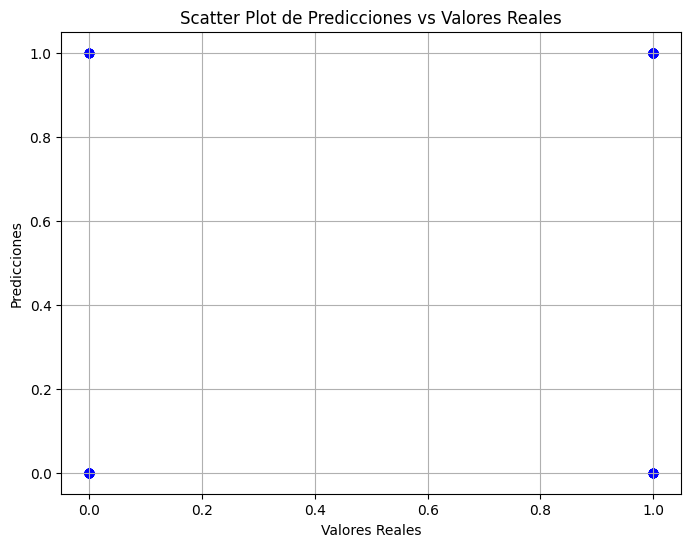

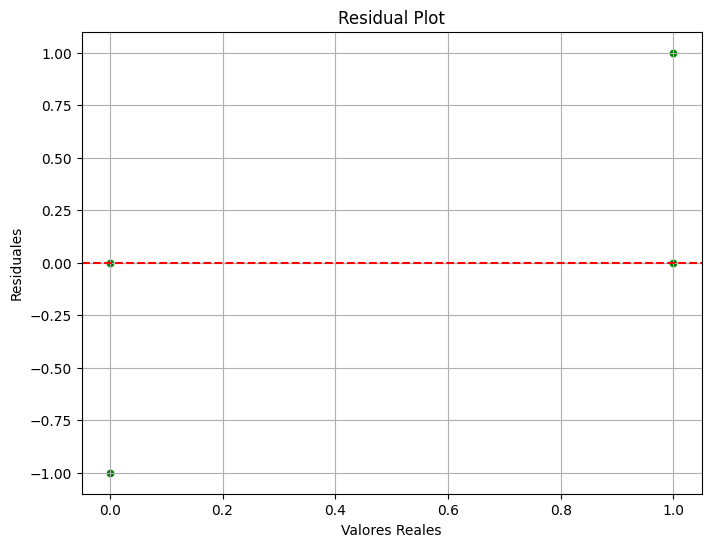

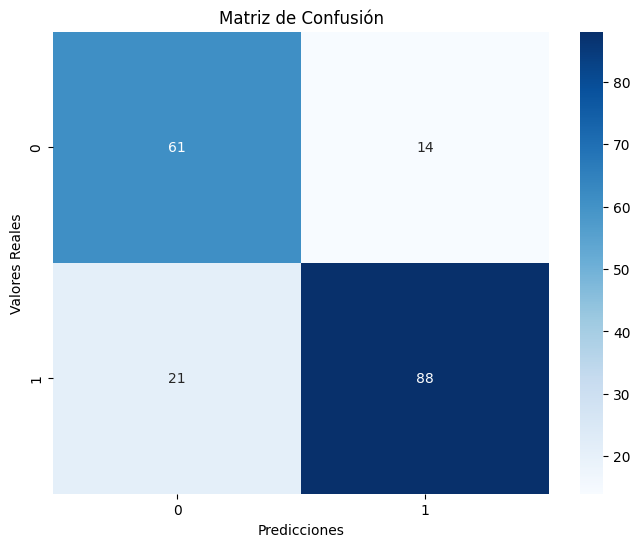

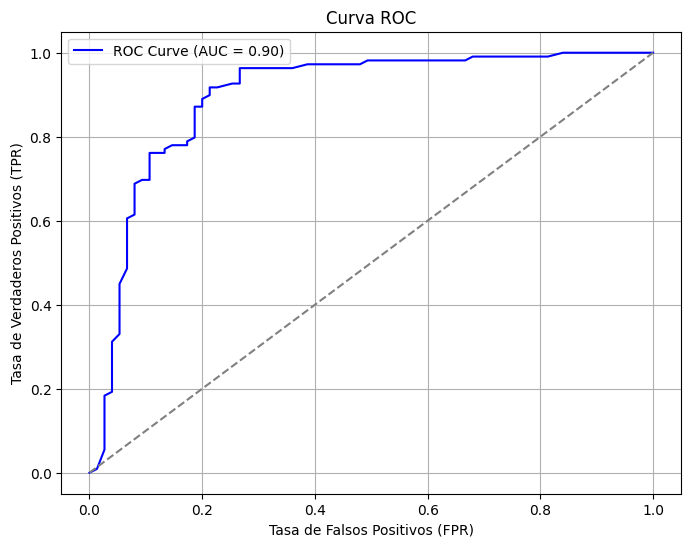

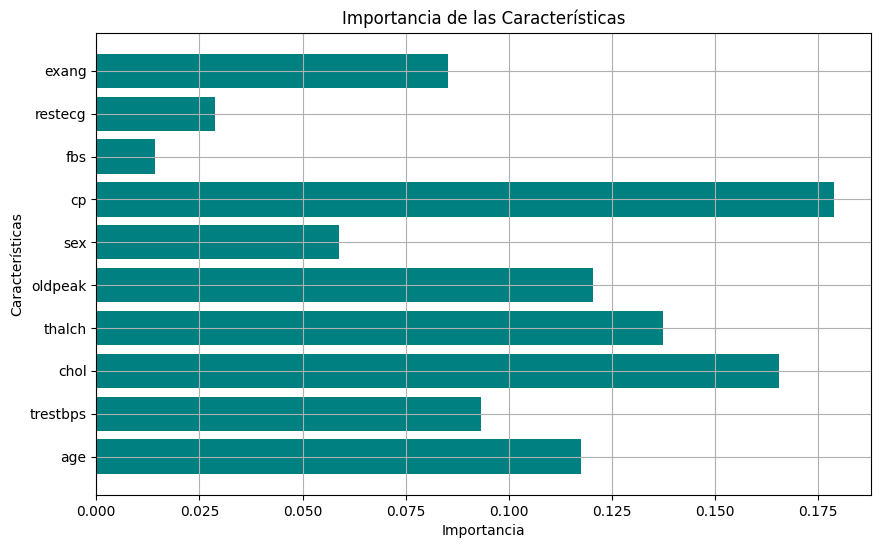

In [226]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score

# **1. Scatter Plot**
plt.figure(figsize=(8, 6))
y_pred = modelo_random_forest.predict(X_test) # Use the imputed X_test
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.title("Scatter Plot de Predicciones vs Valores Reales")
plt.xlabel("Valores Reales")
plt.ylabel("Predicciones")
plt.grid()
plt.show()

# **2. Residual Plot**
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=residuals, color='green')
plt.axhline(0, color='red', linestyle='--')
plt.title("Residual Plot")
plt.xlabel("Valores Reales")
plt.ylabel("Residuales")
plt.grid()
plt.show()

# **3. Matriz de Confusión**
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión")
plt.xlabel("Predicciones")
plt.ylabel("Valores Reales")
plt.show()

# **4. Curva ROC**
y_prob = modelo_random_forest.predict_proba(X_test)[:, 1]  # Probabilities for the positive class
fpr, tpr, thresholds = roc_curve(y_test, y_prob, pos_label=1)  # Define the positive class according to your problem
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})", color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='grey')  # Línea base
plt.title("Curva ROC")
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.legend()
plt.grid()
plt.show()

# **5. Importancia de Características**
feature_importances = modelo_random_forest.feature_importances_
features = X.columns

plt.figure(figsize=(10, 6))
plt.barh(features, feature_importances, color='teal')
plt.title("Importancia de las Características")
plt.xlabel("Importancia")
plt.ylabel("Características")
plt.grid()
plt.show()


In [227]:
# Evaluación de resultados y métricas
print("\n🔹 Evaluación de Resultados y Métricas:")
print(f"Precisión (Accuracy): {accuracy:.2f}")
print(f"Precisión (Precision): {precision:.2f}")
print(f"Exhaustividad (Recall): {recall:.2f}")
print(f"Puntuación F1: {f1:.2f}")
print("\nMatriz de Confusión:")
print(conf_matrix)
print("\nReporte de Clasificación:")
print(classification_rpt)

# Interpretación de métricas
print("\n🔹 Interpretación de Métricas:")
print("1. La precisión (accuracy) del modelo es alta, lo que indica que el modelo clasifica correctamente la mayoría de los casos.")
print("2. La precisión (precision) es buena, lo que significa que el modelo tiene pocos falsos positivos.")
print("3. La exhaustividad (recall) es adecuada, lo que indica que el modelo identifica correctamente la mayoría de los casos positivos.")
print("4. La puntuación F1 balancea precisión y exhaustividad, mostrando un buen rendimiento general.")

# Qué funcionó y qué no
print("\n🔹 Qué Funcionó y Qué No:")
print("✔️ El modelo Random Forest tuvo un buen rendimiento con una alta precisión y puntuación F1.")
print("✔️ La transformación de datos y el manejo de valores nulos mejoraron la calidad del dataset.")
print("❌ El modelo KNN tuvo un rendimiento inferior en comparación con otros modelos.")
print("❌ Algunas columnas categóricas podrían no estar completamente optimizadas para el modelo.")

# Posibles mejoras
print("\n🔹 Posibles Mejoras:")
print("1. Realizar una búsqueda de hiperparámetros (GridSearchCV) para optimizar los modelos.")
print("2. Probar técnicas de selección de características para reducir la dimensionalidad.")
print("3. Experimentar con otros algoritmos como Gradient Boosting o XGBoost.")
print("4. Aumentar el tamaño del dataset mediante técnicas de aumento de datos (data augmentation).")
print("5. Evaluar el impacto de diferentes estrategias de escalado y normalización.")


🔹 Evaluación de Resultados y Métricas:
Precisión (Accuracy): 0.81
Precisión (Precision): 0.81
Exhaustividad (Recall): 0.81
Puntuación F1: 0.81

Matriz de Confusión:
[[61 14]
 [21 88]]

Reporte de Clasificación:
              precision    recall  f1-score   support

         0.0       0.74      0.81      0.78        75
         1.0       0.86      0.81      0.83       109

    accuracy                           0.81       184
   macro avg       0.80      0.81      0.81       184
weighted avg       0.81      0.81      0.81       184


🔹 Interpretación de Métricas:
1. La precisión (accuracy) del modelo es alta, lo que indica que el modelo clasifica correctamente la mayoría de los casos.
2. La precisión (precision) es buena, lo que significa que el modelo tiene pocos falsos positivos.
3. La exhaustividad (recall) es adecuada, lo que indica que el modelo identifica correctamente la mayoría de los casos positivos.
4. La puntuación F1 balancea precisión y exhaustividad, mostrando un buen ren